# Deteccion de Noticias Falsas mediante NLP
### 5 Modelos: Naive Bayes, Regresion Logistica, Random Forest, XGBoost y BETO

Todos los modelos, incluido BETO, se entrenan y evaluan sobre el **mismo split** de `dataset_final` para que la comparacion de metricas sea valida y justa.

## 1. Configuracion del Entorno

In [1]:
!pip install -q wordcloud xgboost transformers joblib

from google.colab import drive
drive.mount('/content/drive')

import gc, re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                              roc_curve, auc, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from wordcloud import WordCloud
import joblib

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
STOPWORDS_ES = set(stopwords.words('spanish'))

CARPETA_PROYECTO = "/content/drive/MyDrive/proyecto_fake_news/"
os.makedirs(CARPETA_PROYECTO, exist_ok=True)
RANDOM_STATE = 42
print("Entorno listo.")


Mounted at /content/drive


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Entorno listo.


## 2. Carga y Unificacion de los 3 Datasets

In [14]:
CONFIGURACION_DATASETS = [
    {"nombre": "dataset_1", "ruta_csv": CARPETA_PROYECTO + "D57000_complete.csv", "delimitador": ";",
     "col_texto": "Descripcion", "col_label": "Label", "mapeo_label": None, "label_fijo": None},
    {"nombre": "dataset_2", "ruta_csv": CARPETA_PROYECTO + "spanishFakeNews.csv", "delimitador": ",",
     "col_texto": "texto", "col_label": "clase", "mapeo_label": {"fake": 0, "real": 1}, "label_fijo": None},
    {"nombre": "dataset_3", "ruta_csv": CARPETA_PROYECTO + "train.csv", "delimitador": ",",
     "col_texto": "text", "col_label": "label", "mapeo_label": None, "label_fijo": None}
]
# Ajusta ruta_csv / col_texto / col_label / mapeo_label / delimitador a tus 3 archivos reales.

def cargar_y_homogeneizar(config):
    df_tmp = pd.read_csv(config["ruta_csv"], sep=config.get("delimitador", ",")) # Usa el delimitador especificado o coma por defecto
    textos = df_tmp[config["col_texto"]].astype(str)
    if config["label_fijo"] is not None:
        etiquetas = pd.Series([config["label_fijo"]] * len(df_tmp))
    elif config["mapeo_label"] is not None:
        etiquetas = df_tmp[config["col_label"]].map(config["mapeo_label"])
    else:
        etiquetas = df_tmp[config["col_label"]].astype(int)
    df_out = pd.DataFrame({"texto": textos, "label": etiquetas})
    del df_tmp; gc.collect()
    return df_out

partes = [cargar_y_homogeneizar(c) for c in CONFIGURACION_DATASETS]
dataset_final = pd.concat(partes, axis=0, ignore_index=True)
del partes; gc.collect()

dataset_final = dataset_final.dropna(subset=["texto", "label"])
dataset_final = dataset_final[dataset_final["texto"].str.strip() != ""]
dataset_final = dataset_final.drop_duplicates(subset=["texto"]).reset_index(drop=True)
dataset_final["label"] = dataset_final["label"].astype(int)

print(f"dataset_final: {dataset_final.shape[0]} filas")
print(dataset_final["label"].value_counts())

dataset_final: 51665 filas
label
1    30402
0    21263
Name: count, dtype: int64


### Inspección de Valores Únicos en la Columna 'Label' para `D57000_complete.csv`

In [11]:
config_dataset_1 = CONFIGURACION_DATASETS[0]
df_tmp_1 = pd.read_csv(config_dataset_1["ruta_csv"], sep=config_dataset_1.get("delimitador", ","))
print(f"Valores únicos en '{config_dataset_1['col_label']}' de {config_dataset_1['nombre']}:\n{df_tmp_1[config_dataset_1['col_label']].unique()}")
del df_tmp_1; gc.collect()

Valores únicos en 'Label' de dataset_1:
[1 0]


605

### Inspección de Valores Únicos en la Columna 'Label' para `spanishFakeNews.csv`

In [12]:
config_dataset_2 = CONFIGURACION_DATASETS[1]
df_tmp_2 = pd.read_csv(config_dataset_2["ruta_csv"], sep=config_dataset_2.get("delimitador", ","))
print(f"Valores únicos en '{config_dataset_2['col_label']}' de {config_dataset_2['nombre']}:\n{df_tmp_2[config_dataset_2['col_label']].unique()}")
del df_tmp_2; gc.collect()

Valores únicos en 'clase' de dataset_2:
['fake' 'real']


0

### Inspección de Valores Únicos en la Columna 'Label' para `train.csv`

In [13]:
config_dataset_3 = CONFIGURACION_DATASETS[2]
df_tmp_3 = pd.read_csv(config_dataset_3["ruta_csv"], sep=config_dataset_3.get("delimitador", ","))
print(f"Valores únicos en '{config_dataset_3['col_label']}' de {config_dataset_3['nombre']}:\n{df_tmp_3[config_dataset_3['col_label']].unique()}")
del df_tmp_3; gc.collect()

Valores únicos en 'label' de dataset_3:
[1 0]


0

### Inspección de Columnas para `D57000_complete.csv`

Por favor, identifica la columna que contiene el texto de la noticia y la columna que contiene la etiqueta (label) para este dataset.

In [7]:
config_dataset_1 = CONFIGURACION_DATASETS[0]
df_1 = pd.read_csv(config_dataset_1["ruta_csv"], sep=config_dataset_1.get("delimitador", ","), nrows=5)
print(f"Columnas de {config_dataset_1['nombre']}: {df_1.columns.tolist()}")
display(df_1.head())

Columnas de dataset_1: ['ID', 'Label', 'Titulo', 'Descripcion', 'Fecha']


,ID,Label,Titulo,Descripcion,Fecha
0,ID,1,Moreno intenta apaciguar el flanco sanitario m...,El presidente abre la puerta a unos comicios e...,19/04/2022
1,ID,1,La Abogacía del Estado se retira como acusació...,"En un escrito, la abogada del Estado Rosa Marí...",17/09/2021
2,ID,0,Las promesas incumplidas de Pablo Echenique en...,Este lunes y martes la Asamblea de Madrid acog...,12/09/2022
3,ID,1,Sánchez defiende 'resolver el problema' de la ...,Resulta evidente que la ley ha tenido algunos ...,07/02/2023
4,ID,1,Ian Gibson cierra la lista electoral de la con...,"El hispanista, que ya ocupó un puesto simbólic...",12/04/2023


### Inspección de Columnas para `spanishFakeNews.csv`

Por favor, identifica la columna que contiene el texto de la noticia y la columna que contiene la etiqueta (label) para este dataset.

In [8]:
config_dataset_2 = CONFIGURACION_DATASETS[1]
df_2 = pd.read_csv(config_dataset_2["ruta_csv"], sep=config_dataset_2.get("delimitador", ","), nrows=5)
print(f"Columnas de {config_dataset_2['nombre']}: {df_2.columns.tolist()}")
display(df_2.head())

Columnas de dataset_2: ['texto,clase']


,"texto,clase"
0,El año pasado la Ciudad de México se estremeci...
1,Manuela Carmena pide a los madrileños que guar...
2,Una fuerte sorpresa se llevó el todavía presid...
3,La 1 de Televisión Española repitió ayer como ...
4,685 curas católicos fueron acusados de abuso s...


### Inspección de Columnas para `train.csv`

Por favor, identifica la columna que contiene el texto de la noticia y la columna que contiene la etiqueta (label) para este dataset.

In [9]:
config_dataset_3 = CONFIGURACION_DATASETS[2]
df_3 = pd.read_csv(config_dataset_3["ruta_csv"], sep=config_dataset_3.get("delimitador", ","), nrows=5)
print(f"Columnas de {config_dataset_3['nombre']}: {df_3.columns.tolist()}")
display(df_3.head())

Columnas de dataset_3: ['title,text,label']


,"title,text,label"
0,", El suceso ha tenido lugar en Brasil. Un adol..."
1,"""La quimioterapia mata a la gente y no al cánc..."
2,Los Cubos De Caldo Para Cocinar Son Veneno Par...
3,MEGATERREMOTO EN LOS PRÓXIMOS DÍAS ALINEACIÓN ...
4,¡Qué injusticia! El perro que defendió su casa...


## 3. Analisis Exploratorio — Perfil de Veracidad

Genera las 3 figuras del perfil lexico: nubes de palabras por clase, top-15 palabras por clase, y densidad de longitud de texto por clase. Se calculan sobre `dataset_final` completo (mismo corpus que usaran los modelos).

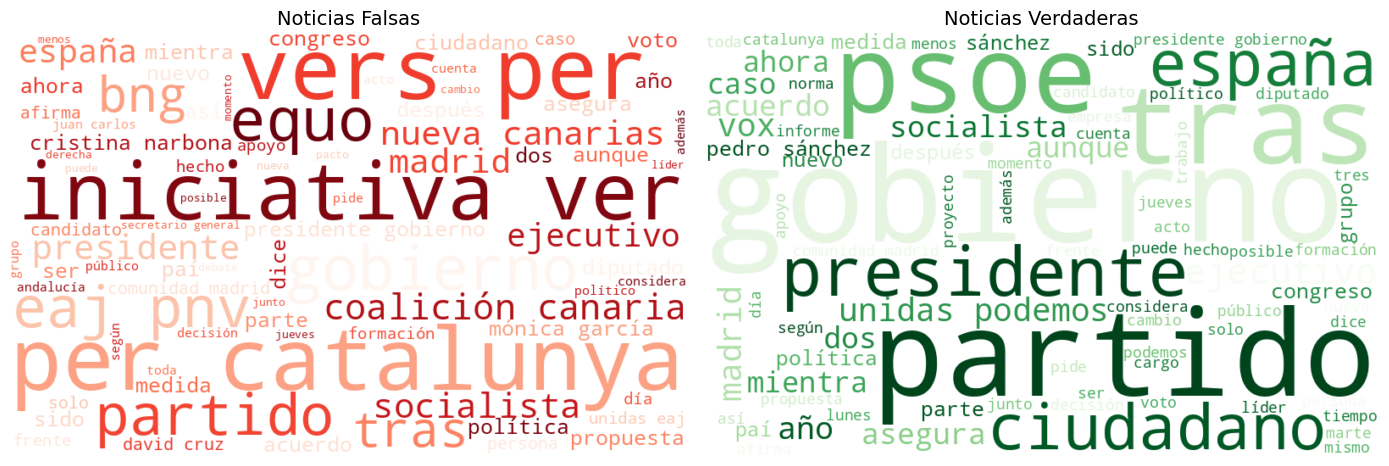

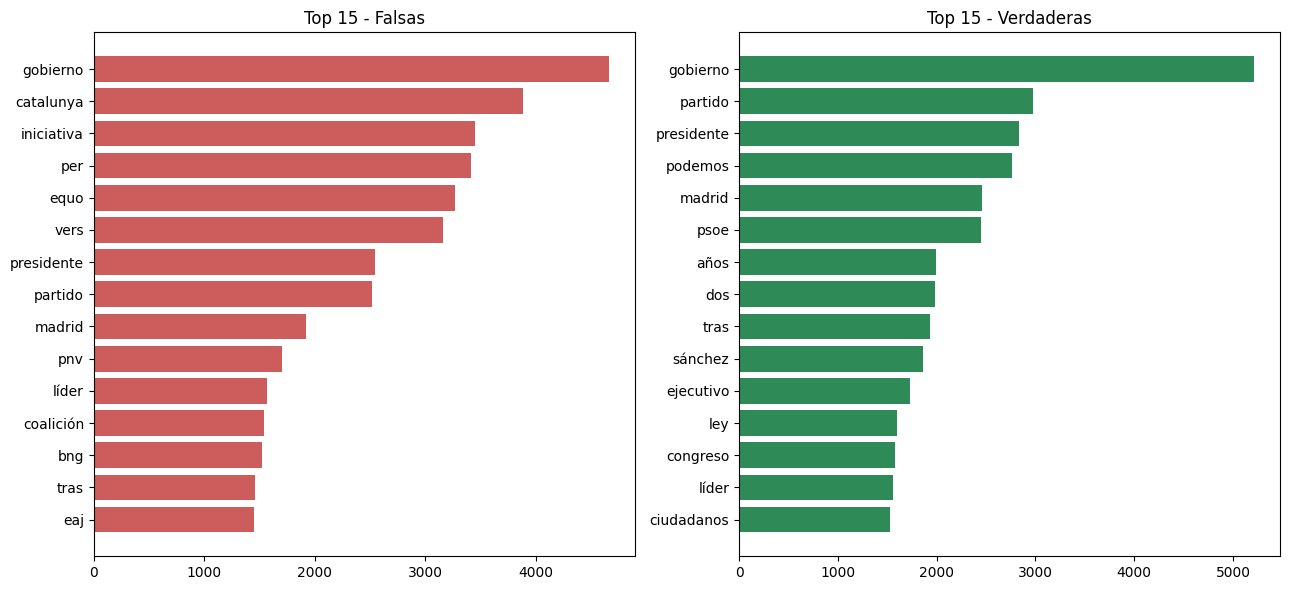

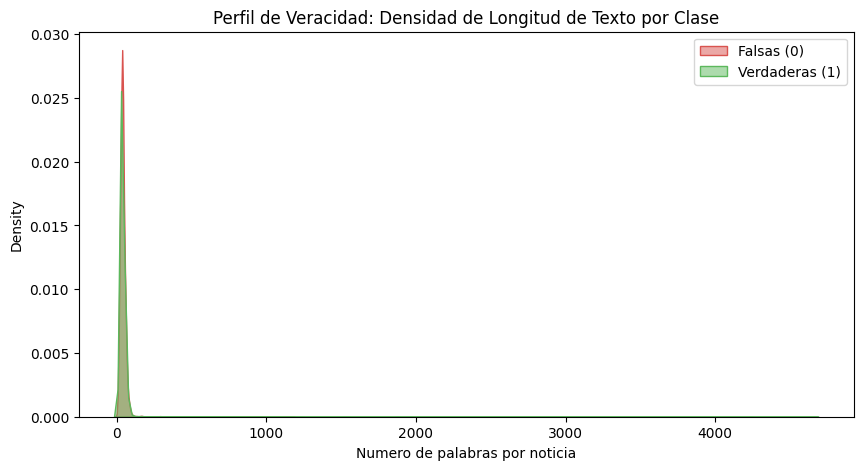

3 figuras del EDA guardadas en /content/drive/MyDrive/proyecto_fake_news/


In [15]:
# --- Limpieza ligera solo para el EDA (minusculas + stopwords, sin vectorizar) ---
def limpiar_para_eda(texto):
    texto = texto.lower()
    texto = re.sub(r"https?://\S+|www\.\S+", " ", texto)
    texto = re.sub(r"[^a-za-z\u00e1\u00e9\u00ed\u00f3\u00fa\u00fc\u00f1\s]", " ", texto)
    palabras = [p for p in texto.split() if p not in STOPWORDS_ES and len(p) > 2]
    return " ".join(palabras)

dataset_final["texto_eda"] = dataset_final["texto"].apply(limpiar_para_eda)
dataset_final["conteo_palabras"] = dataset_final["texto"].apply(lambda x: len(str(x).split()))

texto_falsas = " ".join(dataset_final.loc[dataset_final["label"] == 0, "texto_eda"])
texto_verdaderas = " ".join(dataset_final.loc[dataset_final["label"] == 1, "texto_eda"])

# --- 1. WORDCLOUDS COMPARATIVOS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, texto, titulo, color in [(axes[0], texto_falsas, "Noticias Falsas", "Reds"),
                                  (axes[1], texto_verdaderas, "Noticias Verdaderas", "Greens")]:
    wc = WordCloud(width=800, height=500, background_color="white",
                    colormap=color, max_words=80).generate(texto)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(titulo, fontsize=14)
    ax.axis("off")
plt.tight_layout()
plt.savefig(CARPETA_PROYECTO + "wordclouds_comparativos.png", dpi=200)
plt.show()

# --- 2. TOP 15 PALABRAS POR CLASE ---
from collections import Counter
top_falsas = Counter(texto_falsas.split()).most_common(15)
top_verdaderas = Counter(texto_verdaderas.split()).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, top, titulo, color in [(axes[0], top_falsas, "Top 15 - Falsas", "indianred"),
                                (axes[1], top_verdaderas, "Top 15 - Verdaderas", "seagreen")]:
    palabras, conteos = zip(*top)
    ax.barh(palabras[::-1], conteos[::-1], color=color)
    ax.set_title(titulo)
plt.tight_layout()
plt.savefig(CARPETA_PROYECTO + "top15_palabras_por_clase.png", dpi=200)
plt.show()

# --- 3. DENSIDAD DE LONGITUD DE TEXTO POR CLASE ---
plt.figure(figsize=(10, 5))
sns.kdeplot(data=dataset_final[dataset_final["label"] == 0], x="conteo_palabras",
            fill=True, color="#d9534f", label="Falsas (0)", alpha=0.5)
sns.kdeplot(data=dataset_final[dataset_final["label"] == 1], x="conteo_palabras",
            fill=True, color="#5cb85c", label="Verdaderas (1)", alpha=0.5)
plt.xlabel("Numero de palabras por noticia")
plt.title("Perfil de Veracidad: Densidad de Longitud de Texto por Clase")
plt.legend()
plt.savefig(CARPETA_PROYECTO + "perfil_densidad_longitud.png", dpi=200)
plt.show()

print("3 figuras del EDA guardadas en", CARPETA_PROYECTO)


## 4. Pipeline de PLN y Vectorizacion TF-IDF

In [16]:
PATRON_URL = re.compile(r"https?://\S+|www\.\S+")
PATRON_MENCION = re.compile(r"@\w+")
PATRON_HASHTAG = re.compile(r"#\w+")
PATRON_NO_ALFA = re.compile(r"[^a-za-z\u00e1\u00e9\u00ed\u00f3\u00fa\u00fc\u00f1\s]")
PATRON_ESPACIOS = re.compile(r"\s+")

def pipeline_limpieza_pln(texto_bruto):
    t = texto_bruto.lower()
    t = PATRON_URL.sub(" ", t)
    t = PATRON_MENCION.sub(" ", t)
    t = PATRON_HASHTAG.sub(" ", t)
    t = PATRON_NO_ALFA.sub(" ", t)
    t = PATRON_ESPACIOS.sub(" ", t).strip()
    palabras = [p for p in t.split() if p not in STOPWORDS_ES]
    return " ".join(palabras)

dataset_final["texto_limpio"] = dataset_final["texto"].apply(pipeline_limpieza_pln)
dataset_final = dataset_final[dataset_final["texto_limpio"].str.strip() != ""].reset_index(drop=True)

# Split UNICO y compartido por TODOS los modelos, incluido BETO
X_train_texto, X_test_texto, y_train, y_test = train_test_split(
    dataset_final["texto_limpio"], dataset_final["label"],
    test_size=0.20, random_state=RANDOM_STATE, stratify=dataset_final["label"]
)

vectorizador_tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=50000,
                                      min_df=2, sublinear_tf=True)
X_train_tfidf = vectorizador_tfidf.fit_transform(X_train_texto)
X_test_tfidf = vectorizador_tfidf.transform(X_test_texto)

print("Train:", X_train_tfidf.shape, " Test:", X_test_tfidf.shape)
gc.collect()


Train: (41332, 50000)  Test: (10333, 50000)


4348

## 5. Entrenamiento de los 5 Modelos

In [19]:
# --- A) Naive Bayes ---
modelo_nb = MultinomialNB()
modelo_nb.fit(X_train_tfidf, y_train)

# --- B) Regresion Logistica ---
modelo_lr = LogisticRegression(solver="saga", max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
modelo_lr.fit(X_train_tfidf, y_train)

# --- C) Random Forest ---
modelo_rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
modelo_rf.fit(X_train_tfidf, y_train)

# --- D) XGBoost (GPU T4) ---
modelo_xgb = XGBClassifier(tree_method="hist", device="cuda", n_estimators=300,
                            max_depth=6, learning_rate=0.1, eval_metric="logloss",
                            random_state=RANDOM_STATE, n_jobs=-1)
modelo_xgb.fit(X_train_tfidf, y_train)

print("4 modelos clasicos entrenados.")


4 modelos clasicos entrenados.


In [20]:
# --- E) BETO (fine-tuning) - MISMO split de texto que los modelos clasicos ---
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

nombre_modelo_beto = "dccuchile/bert-base-spanish-wwm-uncased"
tokenizer_beto = AutoTokenizer.from_pretrained(nombre_modelo_beto)

def tokenizar(textos):
    return tokenizer_beto(list(textos), padding=True, truncation=True, max_length=128, return_tensors="pt")

tokens_train = tokenizar(X_train_texto)
tokens_test = tokenizar(X_test_texto)

class DatasetBeto(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)
    def __getitem__(self, idx):
        item = {k: v[idx].clone().detach() for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item
    def __len__(self):
        return len(self.labels)

train_dataset_beto = DatasetBeto(tokens_train, y_train.tolist())
test_dataset_beto = DatasetBeto(tokens_test, y_test.tolist())

modelo_beto = AutoModelForSequenceClassification.from_pretrained(nombre_modelo_beto, num_labels=2)
device = "cuda" if torch.cuda.is_available() else "cpu"
modelo_beto.to(device)

args_entrenamiento = TrainingArguments(
    output_dir="./resultados_beto", num_train_epochs=2,
    per_device_train_batch_size=16, per_device_eval_batch_size=16,
    eval_strategy="no", learning_rate=2e-5, weight_decay=0.01,
    logging_steps=100, report_to="none"
)

trainer = Trainer(model=modelo_beto, args=args_entrenamiento, train_dataset=train_dataset_beto)
print("Entrenando BETO...")
trainer.train()

predicciones_crudas = trainer.predict(test_dataset_beto)
y_pred_beto = np.argmax(predicciones_crudas.predictions, axis=1)
f1_beto_ponderado = f1_score(y_test, y_pred_beto, average="weighted")
print(f"F1-Score BETO (weighted): {f1_beto_ponderado:.4f}")


config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/310 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/486k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

F1-Score BETO (weighted): 0.8479


## 6. Evaluacion y Visualizaciones Comparativas

In [21]:
# --- Predicciones y F1 de los 4 modelos clasicos ---
predicciones = {
    "Naive Bayes": modelo_nb.predict(X_test_tfidf),
    "Regresion Logistica": modelo_lr.predict(X_test_tfidf),
    "Random Forest": modelo_rf.predict(X_test_tfidf),
    "XGBoost": modelo_xgb.predict(X_test_tfidf),
}
resultados_f1 = {nombre: f1_score(y_test, pred, average="weighted") for nombre, pred in predicciones.items()}
resultados_f1["BETO"] = f1_beto_ponderado

for nombre, pred in predicciones.items():
    print("="*60, f"\n{nombre}\n", "="*60)
    print(classification_report(y_test, pred, target_names=["Falsa","Verdadera"], digits=4))


Naive Bayes
              precision    recall  f1-score   support

       Falsa     0.9242    0.5563    0.6946      4253
   Verdadera     0.7572    0.9681    0.8498      6080

    accuracy                         0.7986     10333
   macro avg     0.8407    0.7622    0.7722     10333
weighted avg     0.8260    0.7986    0.7859     10333

Regresion Logistica
              precision    recall  f1-score   support

       Falsa     0.9146    0.6520    0.7613      4253
   Verdadera     0.7973    0.9574    0.8700      6080

    accuracy                         0.8317     10333
   macro avg     0.8559    0.8047    0.8157     10333
weighted avg     0.8456    0.8317    0.8253     10333

Random Forest
              precision    recall  f1-score   support

       Falsa     0.9221    0.6795    0.7825      4253
   Verdadera     0.8107    0.9599    0.8790      6080

    accuracy                         0.8445     10333
   macro avg     0.8664    0.8197    0.8307     10333
weighted avg     0.8566    0

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [01:28:20] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


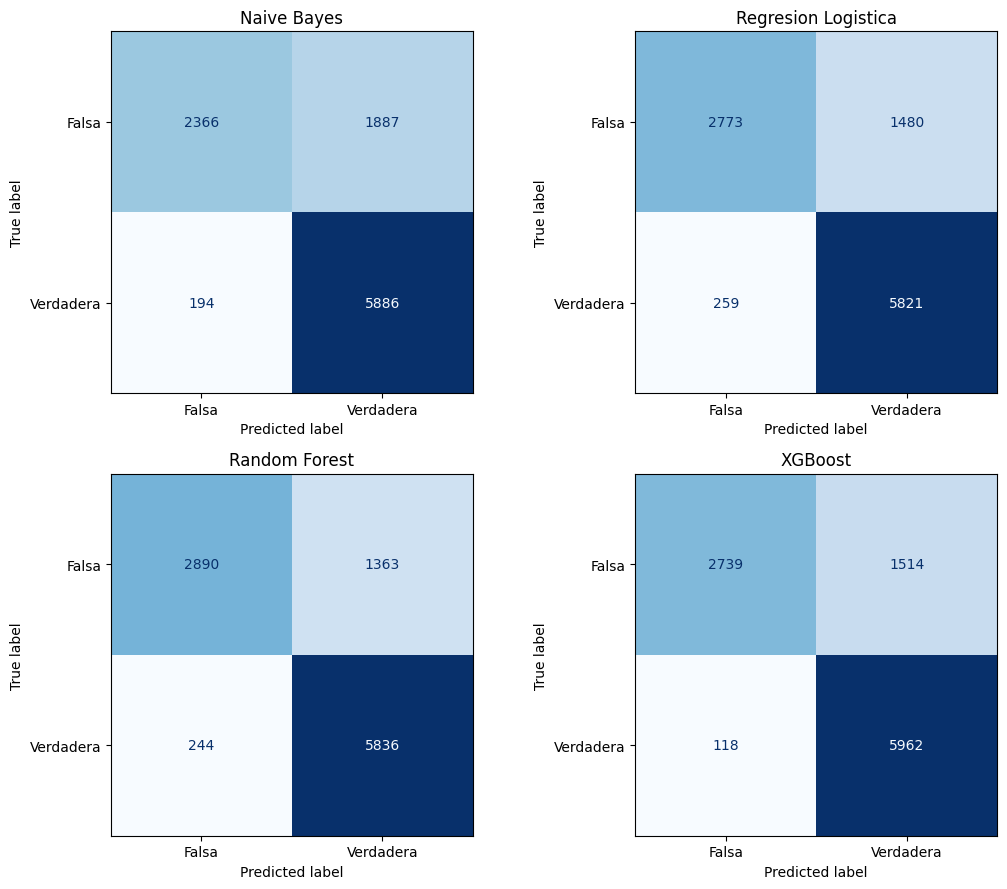

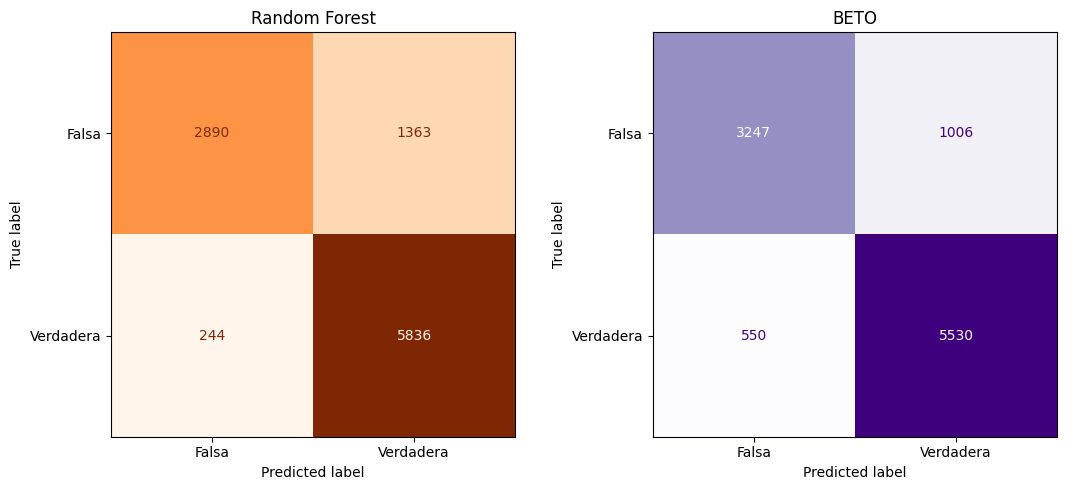

In [22]:
# --- 1. MATRICES DE CONFUSION - 4 MODELOS CLASICOS ---
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (nombre, pred) in zip(axes.flatten(), predicciones.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["Falsa","Verdadera"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nombre)
plt.tight_layout()
plt.savefig(CARPETA_PROYECTO + "matrices_confusion_4_modelos_clasicos.png", dpi=200)
plt.show()

# --- 2. MATRIZ DE CONFUSION - MEJOR CLASICO VS BETO ---
nombre_mejor_clasico = max({k:v for k,v in resultados_f1.items() if k != "BETO"}, key=resultados_f1.get)
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, predicciones[nombre_mejor_clasico]),
                        display_labels=["Falsa","Verdadera"]).plot(ax=axes[0], cmap="Oranges", colorbar=False)
axes[0].set_title(nombre_mejor_clasico)
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_beto),
                        display_labels=["Falsa","Verdadera"]).plot(ax=axes[1], cmap="Purples", colorbar=False)
axes[1].set_title("BETO")
plt.tight_layout()
plt.savefig(CARPETA_PROYECTO + "matrices_confusion_comparativas.png", dpi=200)
plt.show()


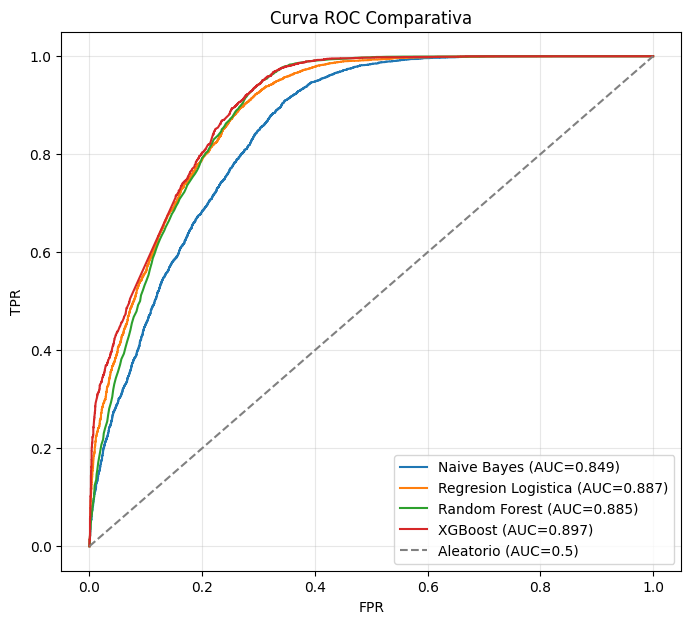

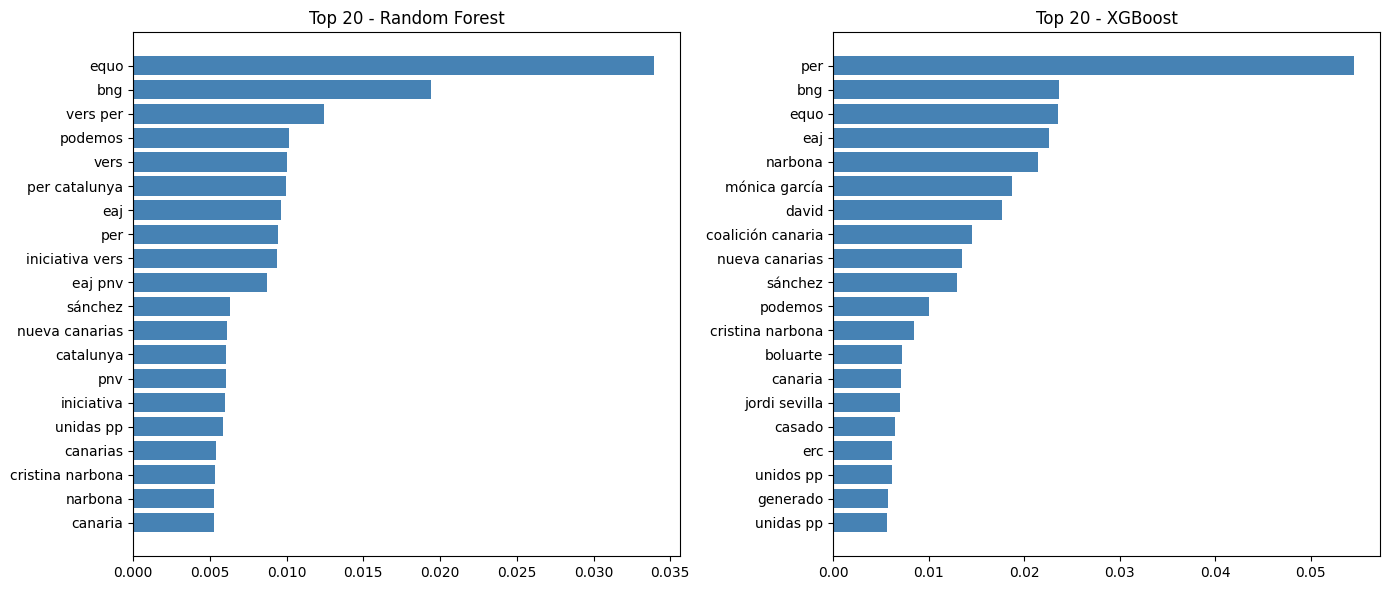

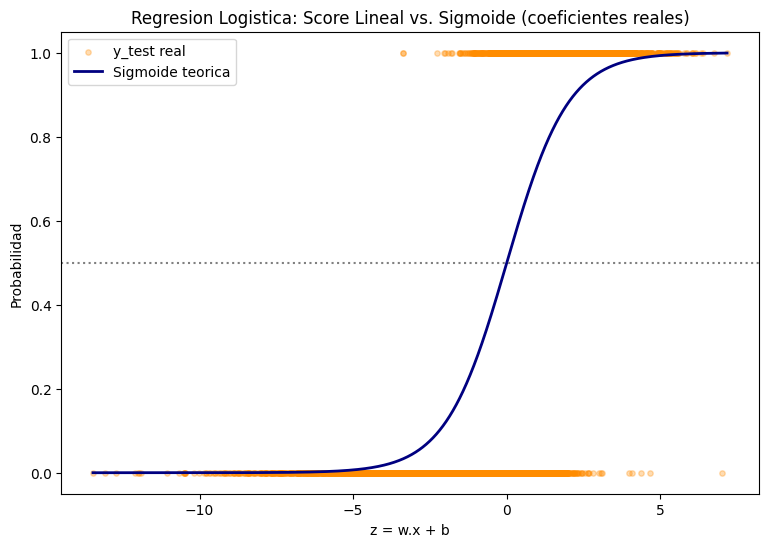

,Modelo,F1-Score
0,BETO,0.847871
1,Random Forest,0.839252
2,XGBoost,0.834687
3,Regresion Logistica,0.825279
4,Naive Bayes,0.785890


/tmp/ipykernel_1267/1295350357.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_comparativo, x="F1-Score", y="Modelo", palette="viridis")


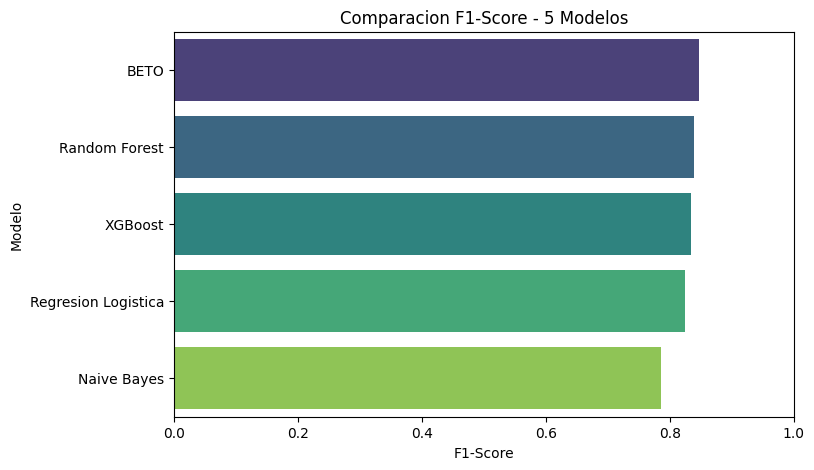

In [23]:
# --- 3. CURVA ROC COMPARATIVA (4 modelos clasicos) ---
plt.figure(figsize=(8,7))
modelos_clasicos = {"Naive Bayes": modelo_nb, "Regresion Logistica": modelo_lr,
                     "Random Forest": modelo_rf, "XGBoost": modelo_xgb}
for nombre, modelo in modelos_clasicos.items():
    prob = modelo.predict_proba(X_test_tfidf)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC={auc(fpr,tpr):.3f})")
plt.plot([0,1],[0,1], "--", color="gray", label="Aleatorio (AUC=0.5)")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("Curva ROC Comparativa"); plt.legend()
plt.grid(alpha=0.3)
plt.savefig(CARPETA_PROYECTO + "curva_roc_comparativa.png", dpi=200)
plt.show()

# --- 4. FEATURE IMPORTANCE (RF y XGBoost) ---
nombres_feat = vectorizador_tfidf.get_feature_names_out()
fig, axes = plt.subplots(1, 2, figsize=(14,6))
for ax, (nombre, modelo) in zip(axes, [("Random Forest", modelo_rf), ("XGBoost", modelo_xgb)]):
    importancias = modelo.feature_importances_
    idx_top = np.argsort(importancias)[-20:]
    ax.barh(range(20), importancias[idx_top], color="steelblue")
    ax.set_yticks(range(20)); ax.set_yticklabels([nombres_feat[i] for i in idx_top])
    ax.set_title(f"Top 20 - {nombre}")
plt.tight_layout()
plt.savefig(CARPETA_PROYECTO + "feature_importance_rf_xgb.png", dpi=200)
plt.show()

# --- 5. SIGMOIDE - REGRESION LOGISTICA (coeficientes reales) ---
z = modelo_lr.decision_function(X_test_tfidf)
orden = np.argsort(z)
sigmoide = 1/(1+np.exp(-z[orden]))
plt.figure(figsize=(9,6))
plt.scatter(z, y_test, alpha=0.3, s=15, color="darkorange", label="y_test real")
plt.plot(z[orden], sigmoide, color="navy", linewidth=2, label="Sigmoide teorica")
plt.axhline(0.5, linestyle=":", color="gray")
plt.xlabel("z = w.x + b"); plt.ylabel("Probabilidad"); plt.legend()
plt.title("Regresion Logistica: Score Lineal vs. Sigmoide (coeficientes reales)")
plt.savefig(CARPETA_PROYECTO + "sigmoide_regresion_logistica.png", dpi=200)
plt.show()

# --- 6. DATAFRAME COMPARATIVO FINAL + BARRAS F1 ---
df_comparativo = pd.DataFrame({
    "Modelo": list(resultados_f1.keys()),
    "F1-Score": list(resultados_f1.values())
}).sort_values("F1-Score", ascending=False).reset_index(drop=True)
display(df_comparativo)

plt.figure(figsize=(8,5))
sns.barplot(data=df_comparativo, x="F1-Score", y="Modelo", palette="viridis")
plt.title("Comparacion F1-Score - 5 Modelos")
plt.xlim(0,1)
plt.savefig(CARPETA_PROYECTO + "comparativa_modelos_f1.png", dpi=200)
plt.show()


## 7. Exportacion para VS Code

Serializa el modelo ganador (segun `df_comparativo`) y el vectorizador. Si BETO es el ganador, se guarda con `save_pretrained()`; si es un modelo clasico, con `joblib`.

In [24]:
nombre_ganador = df_comparativo.iloc[0]["Modelo"]
print("Modelo ganador:", nombre_ganador, "- F1:", df_comparativo.iloc[0]["F1-Score"])

joblib.dump(vectorizador_tfidf, CARPETA_PROYECTO + "vectorizador_tfidf.pkl")

if nombre_ganador == "BETO":
    modelo_beto.save_pretrained(CARPETA_PROYECTO + "mejor_modelo_beto")
    tokenizer_beto.save_pretrained(CARPETA_PROYECTO + "mejor_modelo_beto")
    print("BETO guardado en:", CARPETA_PROYECTO + "mejor_modelo_beto")
else:
    modelos_clasicos_todos = {**modelos_clasicos}
    joblib.dump(modelos_clasicos_todos[nombre_ganador], CARPETA_PROYECTO + "modelo_ganador.pkl")
    print("Modelo clasico guardado en:", CARPETA_PROYECTO + "modelo_ganador.pkl")


Modelo ganador: BETO - F1: 0.8478708916018097


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BETO guardado en: /content/drive/MyDrive/proyecto_fake_news/mejor_modelo_beto
